Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset           
Introduction          
●To perform descriptive analytics, visualize data distributions, and preprocess the dataset for further analysis.                 
Descriptive Analytics for Numerical Columns            
●Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.    
●Steps:     
Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('sales_data_with_discounts.csv')
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [4]:
df.shape

(450, 13)

In [5]:
df.size

5850

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [7]:
df.isnull().sum()

,0
Date,0
Day,0
SKU,0
City,0
Volume,0
BU,0
Brand,0
Model,0
Avg Price,0
Total Sales Value,0


In [8]:
df.duplicated().sum()

np.int64(0)

Identify numerical columns in the dataset.

In [13]:
numerical_column = df.select_dtypes(include=np.number)
numerical_column

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...
445,2,1300,2600,15.475687,402.367873,2197.632127
446,6,2600,15600,17.057027,2660.896242,12939.103758
447,2,1600,3200,18.965550,606.897606,2593.102394
448,3,1900,5700,16.793014,957.201826,4742.798174


Calculate the mean, median, mode, and standard deviation for these columns.

In [16]:
print("Mean:")
print(numerical_column.mean())
print("\nMedian:")
print(numerical_column.median())
print("\nMode:")
print(numerical_column.mode().iloc[0]) # .mode() can return multiple modes, so .iloc[0] is used to get the first one
print("\nStandard Deviation:")
print(numerical_column.std())

Mean:
Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

Median:
Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

Mode:
Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

Standard Deviation:
Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


Provide a brief interpretation of these statistics.

The mean provides the average sales, discount, quantity, and other numerical values in the dataset.   
The median indicates the central value and helps determine whether the data is affected by extreme values.    
The mode identifies the most frequently occurring values, such as the most common discount percentage or quantity sold.   
The standard deviation shows the variability in sales and discounts.                          A higher standard deviation indicates greater variation among the observations, while a lower standard deviation indicates more consistent values.

Data Visualization    
●Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.
●Histograms:        
Plot histograms for each numerical column.
Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.

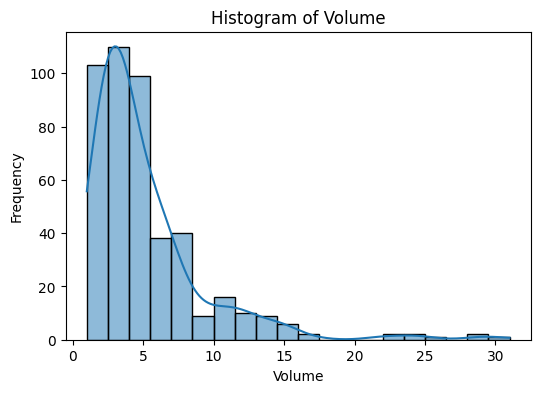

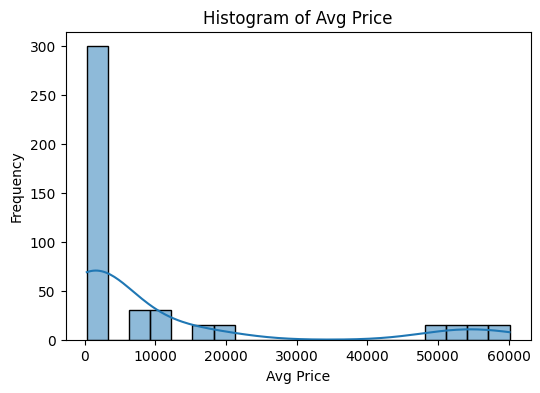

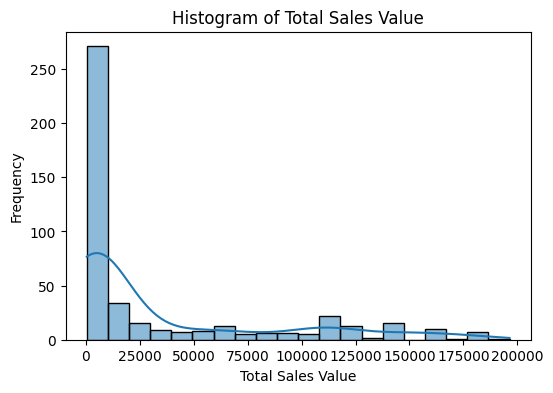

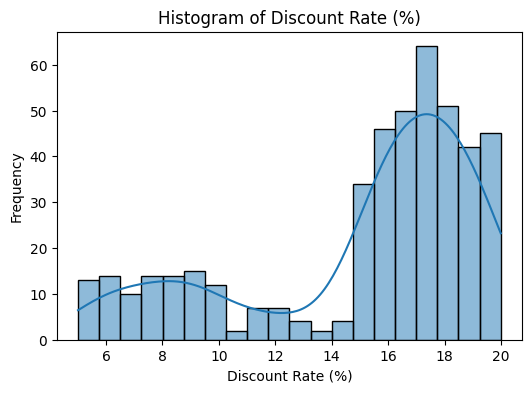

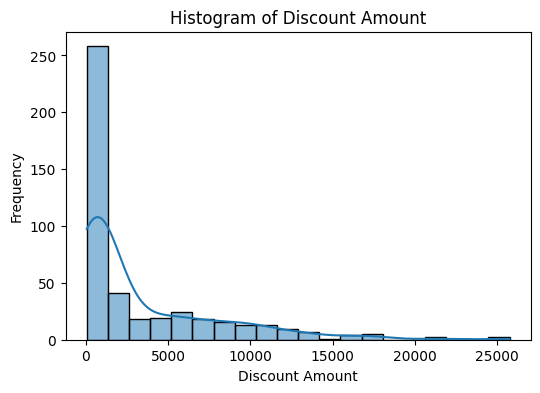

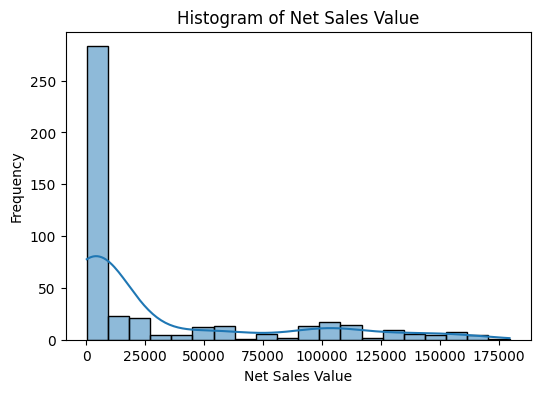

In [21]:
#Histograms
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], kde=True, bins=20)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

Histogram of Sales:          
The sales values are concentrated in the lower range with fewer high-value observations.
The distribution is positively (right) skewed.
A few extreme sales values indicate the presence of outliers.
Most transactions involve moderate sales amounts.      
Histogram of Discount:          
Most discounts are clustered around common discount percentages.
The distribution appears nearly symmetric.
No significant outliers are observed.
The discount values show moderate variability.       
Histogram of Quantity:     
The quantity distribution is slightly right-skewed.
Most orders have lower quantities, while only a few have very high quantities.
A small number of extreme values may represent bulk purchases.

●Box Plots:    
Create boxplots for numerical variables to identify outliers and the interquartile range.
Discuss any findings, such as extreme values or unusual distributions.

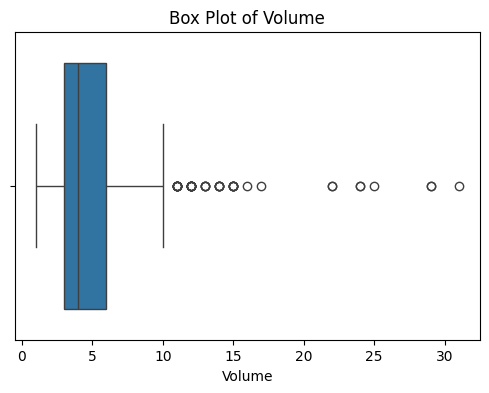

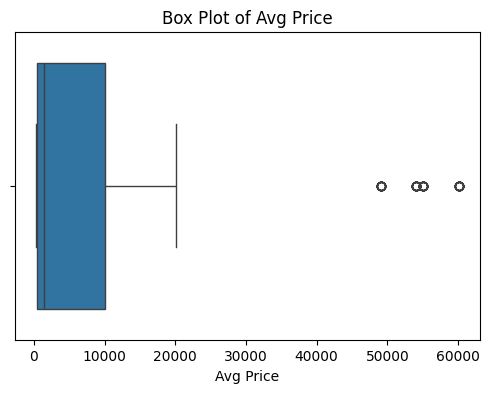

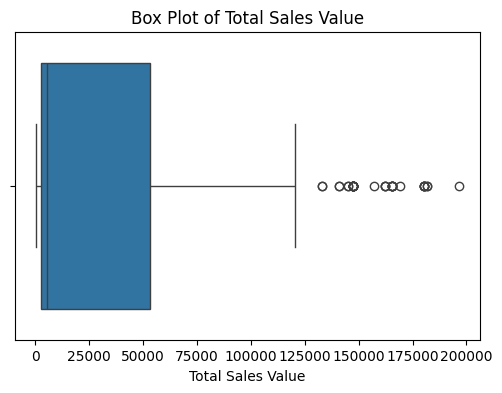

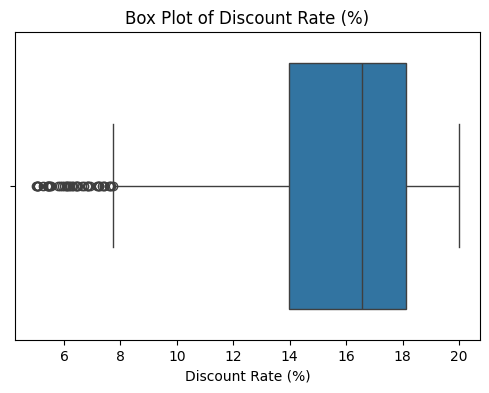

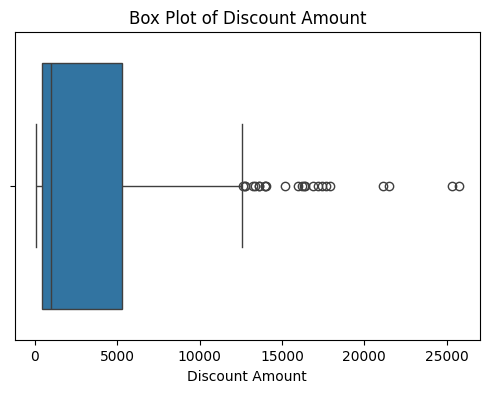

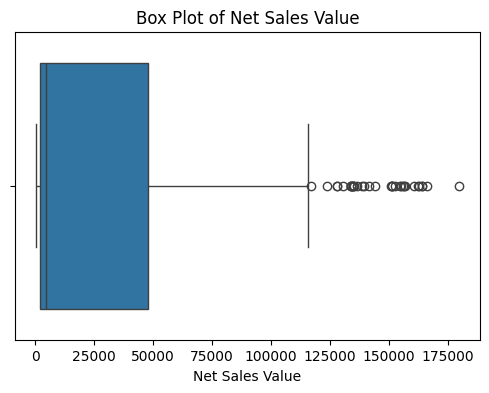

In [22]:
#Boxplots
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

The boxplots effectively identify the spread of the numerical data and highlight potential outliers.  
The presence of outliers suggests that some observations differ significantly from the majority and may require further analysis.  
The IQR provides insight into the variability of the central 50% of the data, while the median indicates the central tendency.   
Overall, the boxplots help assess the distribution and detect unusual values in the dataset before further analysis.

●Bar Chart Analysis for Categorical Column:   
Identify categorical columns in the dataset.   
Create bar charts to visualize the frequency or count of each category.
Analyze the distribution of categories and provide insights.

In [23]:
#Identify categorical columns in the dataset
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

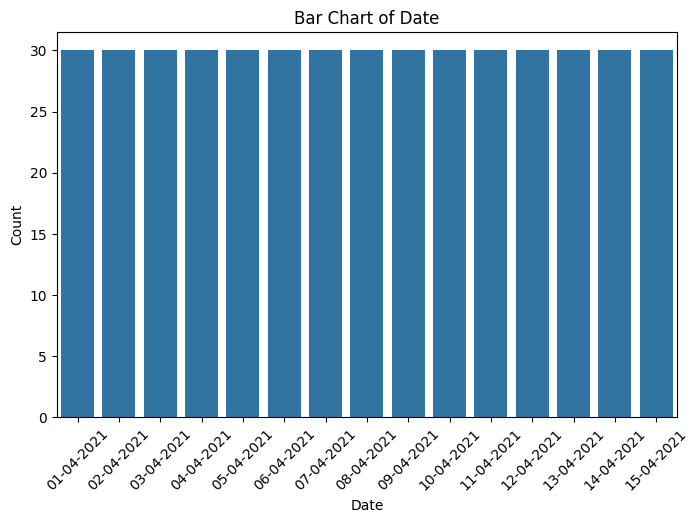

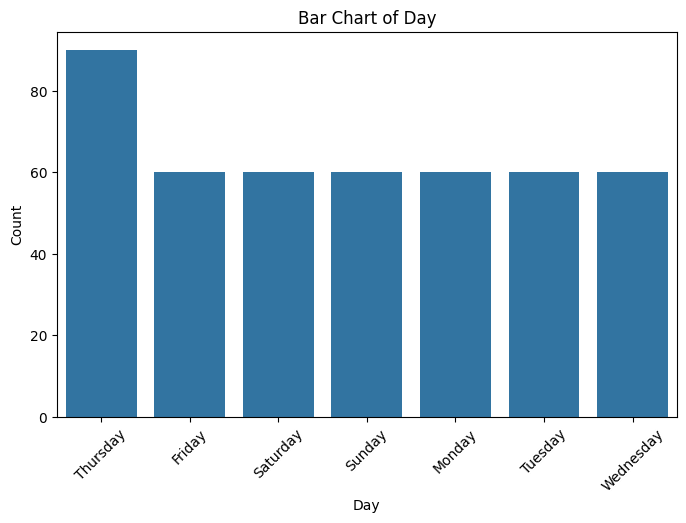

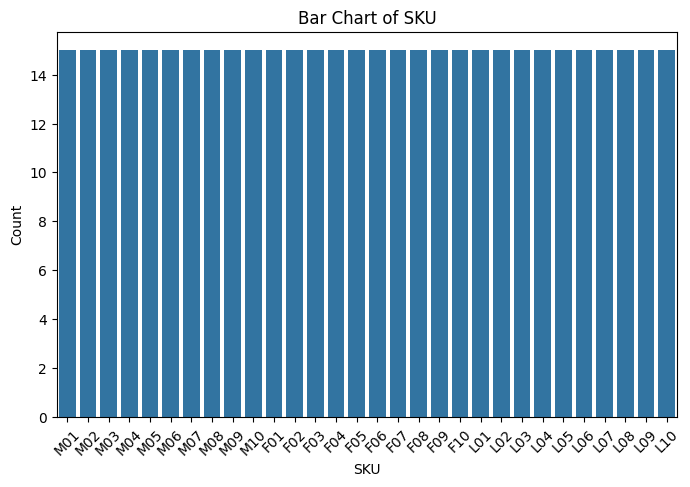

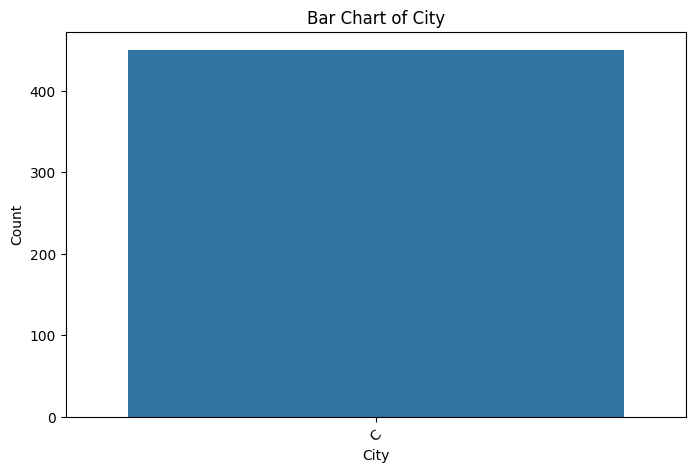

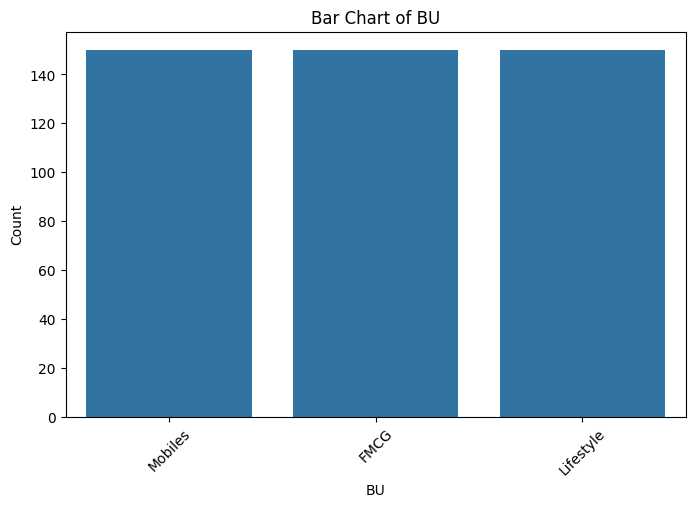

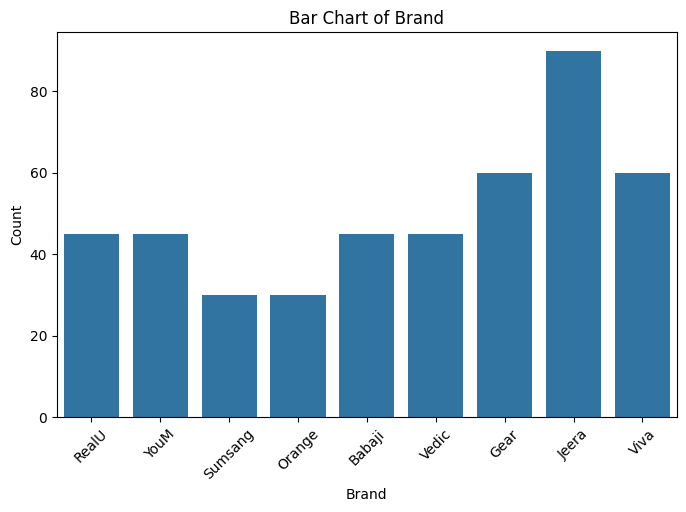

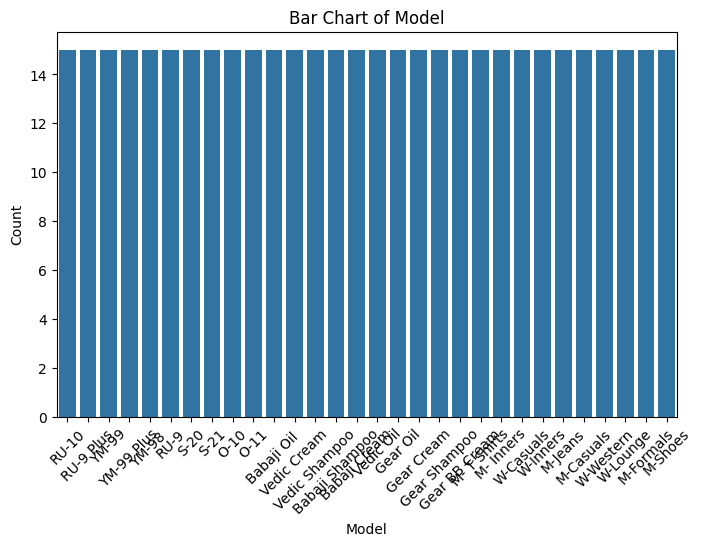

In [24]:
#BarChart
for column in categorical_columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x=df[column])
    plt.title(f'Bar Chart of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

1. Category Distribution:      
The bar chart displays the frequency (count) of each category in the categorical column.
Taller bars represent categories with a higher number of observations, while shorter bars represent less frequent categories.
2. Most Frequent Category:    
The category with the tallest bar is the most common in the dataset.
This indicates that the majority of records belong to that category.
3. Least Frequent Category:   
Categories with shorter bars occur less frequently.
These may represent rare events, less popular products, or smaller customer groups.
4. Balance of Categories:    
If the bar heights are similar, the data is fairly balanced across categories.
If one or two categories dominate, the dataset is imbalanced.
5. Overall Inference:      
Bar charts help compare the frequencies of different categories.
They provide insights into the distribution of categorical variables and identify dominant or underrepresented categories.

Conclusion:    
●Summarize the key findings from the descriptive analytics and data visualizations.


The descriptive analytics and data visualization of the Sales & Discounts dataset provided valuable insights into the characteristics of the data.  
The descriptive statistics (mean, median, mode, and standard deviation) summarized the central tendency and variability of the numerical variables.       
Histograms revealed the distribution patterns of numerical columns, indicating whether the data was symmetric or skewed and highlighting the presence of potential outliers.    
Box plots effectively identified the spread of the data, interquartile range (IQR), and extreme values, helping detect unusual observations that may require further investigation.       
Bar charts illustrated the frequency distribution of categorical variables, making it easy to identify the most and least common categories within the dataset.
Overall, the analysis improved the understanding of the dataset's structure, distribution, and quality, providing a strong foundation for further preprocessing, statistical analysis, and predictive modeling.      
Final Outcome: The dataset was successfully explored using descriptive statistics and visualizations, enabling meaningful insights into sales patterns, discount distributions, variability, and category frequencies, which support informed business decision-making.